# TP 3 — CV & GridSearch : solution commentée

Solution complète du [TP 3](./enonce.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

## Exercice 1 — Comparaison CV

In [2]:
svm_pipe = Pipeline([("sc", StandardScaler()), ("clf", SVC(kernel="rbf"))])
rf = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1)

for name, m in [("svm", svm_pipe), ("rf", rf)]:
    s = cross_val_score(m, X_train, y_train, cv=5, scoring="accuracy")
    print(f"{name}: {s.mean():.4f} ± {s.std():.4f}")

svm: 0.9802 ± 0.0082


rf: 0.9692 ± 0.0162


## Exercice 2 — GridSearchCV

In [3]:
pipe = Pipeline([("sc", StandardScaler()), ("clf", SVC(kernel="rbf"))])
param_grid = {
    "clf__C": [0.1, 1, 10, 100],
    "clf__gamma": ["scale", 0.01, 0.001],
}
gs = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
gs.fit(X_train, y_train)

print("best params:", gs.best_params_)
print(f"best CV acc: {gs.best_score_:.4f}")
print(f"test acc   : {gs.score(X_test, y_test):.4f}")

best params: {'clf__C': 1, 'clf__gamma': 'scale'}
best CV acc: 0.9802
test acc   : 0.9649


## Exercice 3 — Heatmap

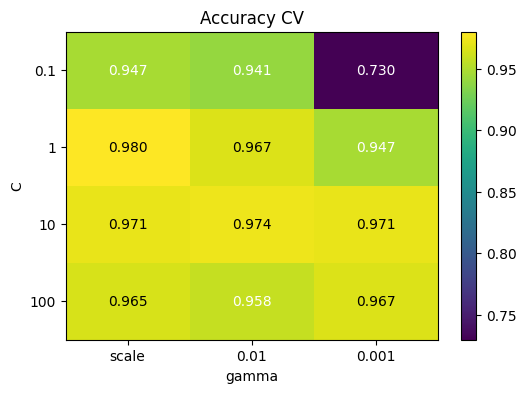

In [4]:
Cs = param_grid["clf__C"]
gammas = param_grid["clf__gamma"]
scores = gs.cv_results_["mean_test_score"].reshape(len(Cs), len(gammas))

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(scores, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(gammas)))
ax.set_xticklabels([str(g) for g in gammas])
ax.set_yticks(range(len(Cs)))
ax.set_yticklabels([str(c) for c in Cs])
ax.set_xlabel("gamma")
ax.set_ylabel("C")
ax.set_title("Accuracy CV")
for i in range(len(Cs)):
    for j in range(len(gammas)):
        ax.text(
            j,
            i,
            f"{scores[i, j]:.3f}",
            ha="center",
            va="center",
            color="white" if scores[i, j] < 0.96 else "black",
        )
fig.colorbar(im, ax=ax)

## Exercice 4 — Évaluation finale

              precision    recall  f1-score   support

   malignant       0.95      0.95      0.95        42
      benign       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



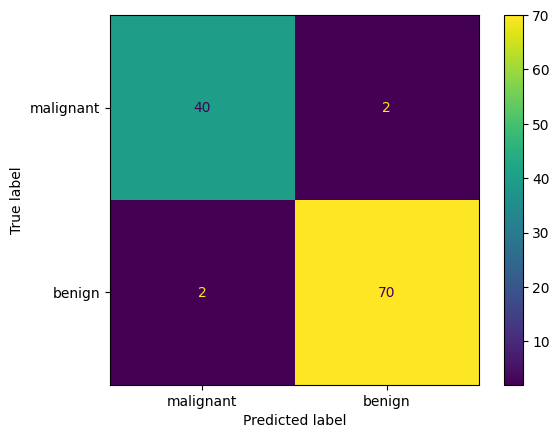

In [5]:
best = gs.best_estimator_
y_pred = best.predict(X_test)
print(classification_report(y_test, y_pred, target_names=data.target_names))
ConfusionMatrixDisplay.from_estimator(best, X_test, y_test, display_labels=data.target_names)

**Discussion** : pour un dépistage de cancer, on veut **maximiser le rappel sur la classe maligne** (manquer un cas malin a un coût humain élevé). Une matrice de confusion qui montre 1-2 faux négatifs sur la classe `malignant` doit être examinée attentivement et un seuil de décision plus conservateur peut être appliqué via `predict_proba` + seuillage manuel.